# Swept pazy wing deformed mode frequencies

Plot the evolution of the first 5 natural frequencies with varying displacement, where we control the displacement by changing the freestream velocity. Comparison between 4 cases:
1. Wing with leading edge tip mass
2. Wing with trailing edge tip mass
3. Wing with leading edge tip mass, with tip inertia corrected for better torsion mode frequency match
4. Straight Pazy wing rotated by 10 degrees

Imports

In [ ]:
from functools import partial

import jax
from jax import Array
from jax import numpy as jnp
from matplotlib import pyplot as plt

from flapjax.aero.flowfields import ConstantFlowField
from flapjax.coupled import CoupledAeroelastic
from flapjax.models.pazy.straight.pazy_wing import generate_pazy_wing
from flapjax.models.pazy.swept.swept_pazy_wing import generate_swept_pazy_wing
from flapjax.utils.print_utils import set_verbosity

Initial variables

In [ ]:
set_verbosity("silent")  # suppress console prints

Discretisation and sweep parameters. Dynamic pressure is swept linearly and converted to freestream velocity magnitude.

In [3]:
n_vel = 256  # number of velocity cases to evaluate
batch_size = 32  # number of velocity cases to evaluate at once

rho = 1.225  # freestream density

# whilst we do here choose an AoA, the resulting data should vary only slightly with a different AoA (other than the maximum deflection achieved)

alpha = jnp.deg2rad(7.0)  # angle of attack
u_inf_mags = jnp.linspace(1e-3, 70.0, n_vel)  # velocity sweep

Build both wing models from the swept beam models

In [ ]:
tip_mass_types = ("LE", "TE", "LE_CORRECTED",)

swept_models = [generate_swept_pazy_wing(flowfield=ConstantFlowField(
    u_inf=jnp.array([0.0, 0.0, 0.0]),  # whilst this is zero, we overwrite it for every instance
    rho=rho,
    relative_motion=True,
),
    aoa=alpha,
    tip_mass=tip_mass,  # type: ignore
    m=12,
    m_star=40,
    node_multiplier=2) for tip_mass in tip_mass_types]

Add a comparison case for the original Pazy wing rotated by 10 degrees.

In [ ]:
swept_models.append(generate_pazy_wing(flowfield=ConstantFlowField(
    u_inf=jnp.array([0.0, 0.0, 0.0]),  # whilst this is zero, we overwrite it for every instance
    rho=rho,
    relative_motion=True,
),
    aoa=alpha,
    m=12,
    m_star=40,
    node_multiplier=2, sweep=jnp.deg2rad(10.0), ))

Per-velocity solve. Swaps the freestream flowfield, obtains static equilibrium, and returns the mid-chord tip Z displacement together with the first 5 natural frequencies about that deformed state.

In [6]:
def modes_at_velocity(u_mag: Array, wing: CoupledAeroelastic) -> tuple[Array, Array]:
    # swap only the flowfield's u_inf
    wing.aero.flowfield = ConstantFlowField(
        u_inf=jnp.array([u_mag, 0.0, 0.0]),
        rho=rho,
        relative_motion=True,
    )
    # find deformation for clamped wing with horseshoe wake
    static_sol = wing.static_solve(
        prescribed_dofs=tuple(range(6)),
        horseshoe=True,
    )
    freqs_, *_ = wing.structure.modal(case=static_sol.structure,
                                      n_modes=5)  # evaluate natural frequencies of structure for given deformation

    tip_z_ = 0.5 * (
            static_sol.aero.zeta_b[0][0, -1, 2] + static_sol.aero.zeta_b[0][-1, -1, 2]
    )  # evaluate mid-chord tip deflection from the deformed aerodynamic grid zeta_b

    return tip_z_, freqs_

Run the sweep across all velocities using `jax.lax.map` with the configured batch size. Apply this for all models.

In [7]:
tip_z_all, freqs_all = zip(
    *[jax.lax.map(partial(modes_at_velocity, wing=model), u_inf_mags, batch_size=batch_size) for model in swept_models])

Plot mode frequency against tip displacement for each of the first 5 modes.

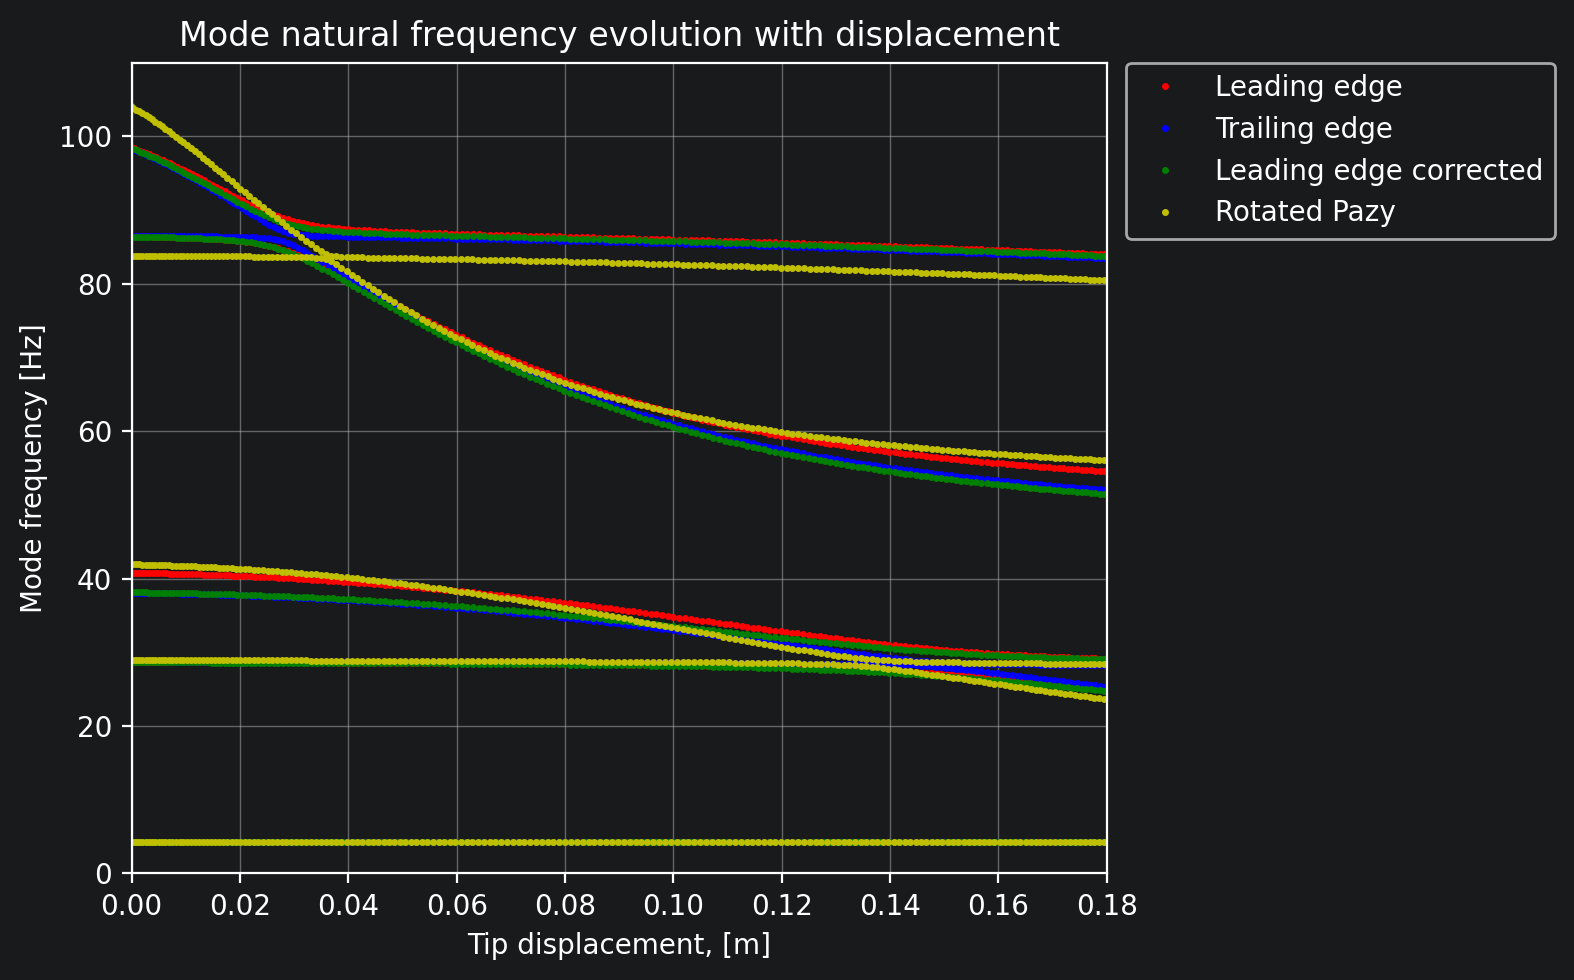

In [12]:
fig, ax = plt.subplots(dpi=200, figsize=(8, 5))
for tip_z, freqs, name, marker in zip(tip_z_all,
                                      freqs_all,
                                      ("Leading edge", "Trailing edge", "Leading edge corrected", "Rotated Pazy"),
                                      ("r.", "b.", "g.", "y.")):
    xs = jnp.broadcast_to(tip_z[:, None], freqs.shape).ravel()
    ax.plot(xs, freqs.ravel(), marker, markersize=3, label=name)
ax.set_xlabel("Tip displacement, [m]")
ax.set_ylabel("Mode frequency [Hz]")
ax.set_title("Mode natural frequency evolution with displacement")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.set_xlim(0.0, 0.18)
ax.set_ylim(0.0, 110.0)
ax.grid(True)
fig.tight_layout()
plt.show()